**This notebook contains 1) data cleaning 2) translation from arabic to english 3) restructuration of text from pdf and web 4) tables preparation to be imported into mysql**

In [2]:
# imports
import pandas as pd
import json
import os
import re
import openpyxl
import time
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import MarianMTModel, MarianTokenizer
from openai import OpenAI
import torch
from tqdm.auto import tqdm
import hashlib
from urllib.parse import urlparse
import matplotlib.pyplot as plt

In [4]:
# source and copy
df_raw_artefacts = pd.read_csv("../data/raw/pdfs/output/csv/artifacts.csv", encoding="utf-8-sig")
df_raw_artf_img = pd.read_csv("../data/raw/pdfs/output/csv/artifact_images.csv", encoding="utf-8-sig")

df_artefacts = df_raw_artefacts.copy()
df_artefacts["langue"] = "ar"

df_img_pdf = df_raw_artf_img.copy()
df_img_pdf= df_img_pdf.drop_duplicates(subset="image_name")

## PART 1 : PDF EXTRACTION CLEANING AND WRANGLING
**Data cleaning**

In [5]:
## artifacts csv file data cleaning
# basic cleaning
def clean_text(x):
    if pd.isna(x):
        return None
    x = str(x)
    x = x.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x if x else None

# get the link of the art dealer
def extract_http_link(row):
    for value in row:
        if value is None:
            continue

        text = str(value).strip()

        if text.startswith(("http://", "https://")):
            return text

    return None
    
# clean object column (regex)
for col in df_artefacts.columns:
    if df_artefacts[col].dtype == "object":
        df_artefacts[col] = df_clean[col].apply(clean_text)

# standardize empty/null values
df_artefacts = df_artefacts.replace({"": None, "null": None, "None": None})

# extract and locate links in one column
df_artefacts["link"] = df_artefacts.apply(extract_http_link, axis=1)


# json cleaning
df_artefacts["related_images"] = df_artefacts["related_images"].apply(
    lambda x: json.loads(x) if pd.notna(x) else []
)

df_artefacts = df_artefacts.drop(columns=["related_images", "langue"], errors="ignore")

**Translation from arabic to english with MarianMT**

Due to weak translation, code has been kept as a comment to further explore more into-depth and keep track of it. However, we had to try other options.

In [ ]:
"""# This section focuses on the translation of all text relevant columns from arabic to english
# token input - huggin face
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)

# tokenizer and transformer
model_name = "Helsinki-NLP/opus-mt-ar-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

print("Device:", device)

# tqdm on apply to monitor progress
tqdm.pandas()

# functions
def contains_arabic(text):
    text = str(text)
    return bool(re.search(r"[\u0600-\u06FF]", text))

def smart_translate(text, max_length=256):
    text = "" if pd.isna(text) else str(text).strip()

    if not text:
        return ""

    # if no arabic, don't change - for the link for example
    if not contains_arabic(text):
        return text

    try:
        with torch.no_grad():
            tokens = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_length
            ).to(device)

            generated = model.generate(**tokens, max_length=max_length)
            result = tokenizer.decode(generated[0], skip_special_tokens=True)

        return result

    except Exception as e:
        print(f"Translation error for: {text[:80]}... -> {e}")
        return text


def translate_one_column(df, col_name):
    new_col = f"{col_name}_en"

    df[new_col] = (
        df[col_name]
        .fillna("")
        .astype(str)
        .progress_apply(smart_translate)
    )

    print(f"Column created : {new_col}")
    return df

cols_to_translate = ["type","description_text_long","material","period","dimensions","name_museum_auction","statuts","note"]
for col in cols_to_translate: df_artefacts = translate_one_column(df_artefacts, col)"""

**Data cleaning suite**

In [7]:
# Cleaning columns names (BOM)
df_artefacts.columns = df_artefacts.columns.str.replace("\ufeff", "", regex=False).str.strip()

# Clean text for matching column
def clean_for_matching(text):
    text = "" if pd.isna(text) else str(text)
    # remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # remove remaining arabic
    text = re.sub(r"[\u0600-\u06FF]+", " ", text)
    # remove weird punctuation
    text = re.sub(r"[^A-Za-z0-9\s\-.,;:()]", " ", text)
    # only one space
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Removing duplicated words 
def remove_consecutive_duplicates(text):
    words = text.split()
    if not words:
        return ""
    cleaned = [words[0]]
    for w in words[1:]:
        if w.lower() != cleaned[-1].lower():
            cleaned.append(w)
    return " ".join(cleaned)

# Add a column concatenating all columns (due to csv parsing repetitive issues)
cols_for_text = [
    "type",
    "description_text_long",
    "material",
    "period",
    "dimensions",
    "name_museum_auction",
    "status",
    "note"
]

# Apply functions 
df_artefacts["text_for_matching"] = (
    df_artefacts[cols_for_text]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .apply(clean_for_matching)
    .apply(remove_consecutive_duplicates)
)

**Web links as source for art_dealer_image_extraction.py and art_dealer_text_extraction.py**

In [9]:
# Create a specific csv for art dealers webpages (see .py files)
df_web_links = df_artefacts[["artifact_id", "link"]]
df_web_links.to_csv("../data/raw/web_links.csv", index=False, encoding="utf-8-sig")

# You need to run .py files before going further in the notebook

## PART 2: DATA WRANGLING FROM ART DEALER IMAGE AND TEXT EXTRACTION

**Parent dataset including descriptive and normalized fields for both web and pdf sources**

Restructure texts from both pdf and web sources to optimize comparison later and rebuild comprehensive dataset, with structured LLM-extracted for each artefact.

The objectives are: 1) rephrase both text 2) extract information from web and pdf artifact description to rebuild and fill fields. Indeed previous translation and restructuration did not meet expectations.

In [ ]:
# output from ART_DEALERS_EXTRACTION_TEXT.py

#web_text = pd.read_csv("../data/raw/artefacts_with_web.csv", sep = ';', encoding="utf-8")

# df in memory (above)
pdf_text = df_artefacts[["artifact_id","pdf_name","page_num","link", "text_for_matching"]]
df_merged = web_text.merge(
    pdf_text,
    on="artifact_id",
    how="outer"
)

load_dotenv()
USE_OPENAI = False #dry run
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

#Testing code
OUTPUT_CSV = "../data/raw/pdfs/dry_run/pdf_web_artefacts.csv"
#OUTPUT_CSV = "../data/raw/pdf_web_artefacts.csv"

COLUMN_1 = "text_for_matching_web"
COLUMN_2 = "text_for_matching"

# retrieve information from web description
OUTPUT_PRICE_COL = "price"
OUTPUT_CURRENCY_COL = "currency"
OUTPUT_SHORT_COL = "wb_txt_shrt"
OUTPUT_LONG_COL = "wb_txt_lg"

# retrieve information from pdf description
OUTPUT_COL2_DESC = "pdf_upgrd_description"  
OUTPUT_COL2_TYPE = "type"
OUTPUT_COL2_DET = "detail"
OUTPUT_COL2_MAT = "material"
OUTPUT_COL2_ICON = "iconography"
OUTPUT_COL2_PRDG = "period_general"
OUTPUT_COL2_PRDP = "period_precise"


REQUEST_DELAY_SECONDS = 1
MAX_RETRIES = 3

if USE_OPENAI and not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is missing from environment variables.")

client = OpenAI(api_key=OPENAI_API_KEY) if USE_OPENAI else None

SYSTEM_PROMPT_MAIN = """You are an expert in writing archaeological object records for museum databases.

Your task is to transform the provided text into a structured, detailed, neutral description.

STRICT RULES:
- Always begin with the object type, followed by the main material.
- Keep only factual information about the object.
- Remove commercial mentions.
- Do not invent anything.
- Do not infer beyond the source text.
- Preserve technical vocabulary (materials, techniques, typology, shape, dimensions, period).
- Rewrite in clear and fluent English.
- Produce dense and informative descriptions.

The output must contain:
- a price field
- a currency field
- a short paragraph
- a long paragraph

CONTENT RULES:
- The short paragraph must be concise, factual, and written in one paragraph.
- The long paragraph must be more detailed, still factual, and written in one paragraph.
- If price or currency is not explicitly present, return an empty string for that field.
- If some descriptive information is missing, do not invent it.

OUTPUT FORMAT:
Return only valid JSON with exactly these keys:
price
currency
wb_txt_shrt
wb_txt_lg
"""

SYSTEM_PROMPT_COL2 = """You are an expert in writing archaeological object records for museum databases.

Your task is to transform the provided text into a structured, detailed, neutral description.

STRICT RULES:
- Always begin with the object type, followed by the main material.
- Keep only factual information about the object.
- Remove commercial mentions.
- Do not invent anything.
- Do not infer beyond the source text.
- Preserve technical vocabulary (materials, techniques, typology, shape, dimensions, period).
- Rewrite in clear and fluent English.
- Produce a dense and informative description.

The output must contain:
- a type field
- a detail field
- a material field
- an iconography field
- a period_general field
- a period_precise field
- a long paragraph

CONTENT RULES:
- The type field should not exceed 10 unique values. 
- If some types have close meaning (like coins and currency), group them and kepp the original type in the detai field.
- The material hould not exceed 10 unique values.
- Normalize century formats (e.g., "2 century", "2th century" → "2nd century")
- Remove duplicates
- Keep only one version of each period
- Preserve historically meaningful labels (e.g., "Late Antiquity", "Islamic medieval", "South Arabian antiquity")
- Standardize spelling and capitalization
- Replace "unknown" with a single "Unknown"
- Ensure all centuries follow the format: "Xst/Xnd/Xrd/Xth century"
- The long paragraph must be more detailed, still factual, and written in one paragraph.
- If some descriptive information is missing, do not invent it, fill with 'unknown'.


OUTPUT FORMAT:
Return only valid JSON with exactly these keys:
- type
- detail
- material
- iconography
- period_general
- period_precise
- pdf_upgrd_description

"""

def clean_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def call_llm_main(source_text: str) -> dict:
    user_prompt = f"""Source text:
{source_text}

Return only JSON.
"""

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_MAIN},
            {"role": "user", "content": user_prompt},
        ],
    )

    content = response.choices[0].message.content
    data_web = json.loads(content)

    return {
        OUTPUT_PRICE_COL: clean_text(data_web.get("price", "")),
        OUTPUT_CURRENCY_COL: clean_text(data_web.get("currency", "")),
        OUTPUT_SHORT_COL: clean_text(data_web.get("wb_txt_shrt", "")),
        OUTPUT_LONG_COL: clean_text(data_web.get("wb_txt_lg", "")),
    }

def call_llm_col2(source_text: str) -> dict:
    user_prompt = f"""Source text:
{source_text}

Return only JSON.
"""

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_COL2},
            {"role": "user", "content": user_prompt},
        ],
    )

    content = response.choices[0].message.content
    data_pdf = json.loads(content)

    return {
        OUTPUT_COL2_DESC: clean_text(data_pdf.get("pdf_upgrd_description", "")),  
        OUTPUT_COL2_TYPE: clean_text(data_pdf.get("type", "")),  
        OUTPUT_COL2_DET: clean_text(data_pdf.get("detail", "")),  
        OUTPUT_COL2_MAT: clean_text(data_pdf.get("material", "")),  
        OUTPUT_COL2_ICON: clean_text(data_pdf.get("iconography", "")),  
        OUTPUT_COL2_PRDG: clean_text(data_pdf.get("period_general", "")),  
        OUTPUT_COL2_PRDP: clean_text(data_pdf.get("period_precise", "")),  
    }


def safe_call_main(source_text: str) -> dict:
    if not USE_OPENAI:
        print("[DRY RUN] web text skipped")
        return {
            OUTPUT_PRICE_COL: "",
            OUTPUT_CURRENCY_COL: "",
            OUTPUT_SHORT_COL: "",
            OUTPUT_LONG_COL: "",
        }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return call_llm_main(source_text)
        except Exception:
            if attempt < MAX_RETRIES:
                time.sleep(REQUEST_DELAY_SECONDS * attempt)
            else:
                return {
                    OUTPUT_PRICE_COL: "",
                    OUTPUT_CURRENCY_COL: "",
                    OUTPUT_SHORT_COL: "",
                    OUTPUT_LONG_COL: "",
                }

def safe_call_col2(source_text: str) -> dict:
    if not USE_OPENAI:
        print("[DRY RUN] pdf text skipped")
        return {
            OUTPUT_COL2_DESC: "",
            OUTPUT_COL2_TYPE: "",
            OUTPUT_COL2_DET: "",
            OUTPUT_COL2_MAT: "",
            OUTPUT_COL2_ICON: "",
            OUTPUT_COL2_PRDG: "",
            OUTPUT_COL2_PRDP: "",
        }

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return call_llm_col2(source_text)
        except Exception:
            if attempt < MAX_RETRIES:
                time.sleep(REQUEST_DELAY_SECONDS * attempt)
            else:
                return {
                    OUTPUT_COL2_DESC: "",
                    OUTPUT_COL2_TYPE: "",
                    OUTPUT_COL2_DET: "",
                    OUTPUT_COL2_MAT: "",
                    OUTPUT_COL2_ICON: "",
                    OUTPUT_COL2_PRDG: "",
                    OUTPUT_COL2_PRDP: "",
                }

                
def process_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    main_results = []
    col2_results = []

    for _, row in df.iterrows():
        text_1 = clean_text(row.get(COLUMN_1, ""))
        text_2 = clean_text(row.get(COLUMN_2, ""))

        if text_1:
            main_result = safe_call_main(text_1)
        else:
            main_result = {
                OUTPUT_PRICE_COL: "",
                OUTPUT_CURRENCY_COL: "",
                OUTPUT_SHORT_COL: "",
                OUTPUT_LONG_COL: "",
            }

        if text_2:
            col2_result = safe_call_col2(text_2)
        else:
            col2_result = {
                OUTPUT_COL2_DESC: "",
                OUTPUT_COL2_TYPE: "",
                OUTPUT_COL2_DET: "",
                OUTPUT_COL2_MAT: "",
                OUTPUT_COL2_ICON: "",
                OUTPUT_COL2_PRDG: "",
                OUTPUT_COL2_PRDP: "",
            }

        main_results.append(main_result)
        col2_results.append(col2_result)

        if USE_OPENAI:
            time.sleep(REQUEST_DELAY_SECONDS)

    main_results_df = pd.DataFrame(main_results)
    col2_results_df = pd.DataFrame(col2_results)

    return pd.concat(
        [df.reset_index(drop=True), main_results_df, col2_results_df],
        axis=1
    )


def main() -> None:
    df_result = process_dataframe(df_merged)
    df_result.to_csv(OUTPUT_CSV, sep=";", index=False, encoding="utf-8-sig")
    print(f"Saved: {OUTPUT_CSV}")


if __name__ == "__main__":
    main()

**Clean web_photos folder**

Despite previous selection in extracting images, duplicates could be observed.

In [16]:
### Script to clean web images folder

web_images_folder = "../figures/web_photos/"

# get an identifier
def hash_file(path):
    #get the unique hash MD5 of the image
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

# main function
def remove_duplicate_images(folder):
    seen_hashes = set()
    removed_images = []
    
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        
        # ignore subfolders
        if not os.path.isfile(img_path):
            continue
        
        try:
            h = hash_file(img_path)
        except PermissionError:
            print(f"Permission refused for {img_path}, skipping ...")
            continue
        
        if h in seen_hashes:
            os.remove(img_path)
            removed_images.append(filename)
        else:
            seen_hashes.add(h)
    
    print(f"{len(removed_images)} removed duplicates")
    if removed_images:
        print("Deleted duplicated images :", removed_images)

# Apply function to folder
remove_duplicate_images(web_images_folder)

0 removed duplicates


**Clean pdf and web csv files**

To match folder files

In [19]:
# web photos listing updating after deleting duplicates
extensions = (".png", ".webp", ".jpeg", ".jpg")

# list of folder files (directory above)

web_files = [f for f in os.listdir(web_images_folder) if f.lower().endswith(extensions)]
web_images = pd.DataFrame(web_files, columns=["image_name"])

# previous extracted images csv from ART_DEALERS_EXTRACTION_IMAGES.py

extracted_web_photos = pd.read_csv("../data/raw/web_photos_manifest.csv", sep = ';', encoding="utf-8-sig")

# merge to get additional info

df_web_images = web_images.merge(extracted_web_photos, how="left", on="image_name")
#df_web_images.to_csv("../data/raw/web_photos.csv", sep = ';', encoding="utf-8-sig")

In [21]:
# PDF images folder (note: images have been displaced from data\raw\pdfs\output\selected_artifact_images

pdf_images_folder = "../figures/pdf_images" 
extensions = (".png")

# list of folder files
pdf_files = [f for f in os.listdir(pdf_images_folder) if f.lower().endswith(extensions)]

pdf_img_folder = pd.DataFrame(pdf_files, columns=["image_name"])
df_pdf_images = pdf_img_folder.merge(df_img_pdf, how="left", on="image_name")
#df_pdf_image.to_csv("../data/raw/pdf_images.csv", sep = ';', encoding="utf-8-sig")

**Sanitizing data for final relational db**

Some residual inconsistencies remain, especially Arabic characters persisting in several columns across multiple files, requiring an additional round of regex-based cleaning.

In [3]:
# define a common function for all regex issues 
import unicodedata
from ftfy import fix_text

def clean_text_and_pray(x):
    if pd.isna(x):
        return ""
    x = fix_text(x) #clean weird chars
    x = str(x) #to add before try
    x = x.replace("Ã—", "×")  
    x = x.replace("â€“", "–") 
    x = x.replace("â€”", "—")
    x = x.replace("â€™", "’")
    x = x.replace("â€˜", "‘")
    x = x.replace("â€œ", "“")
    x = x.replace("â€\x9d", "”")
    x = x.replace("Â ", " ")
    x = x.replace("Â", "")
    try:
       x = x.encode("latin1").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    x = unicodedata.normalize("NFKC",x) # normalization unicode
    x = x.replace("\n"," ").replace("\r"," ").replace("\t"," ") # tabs and backlines
    x = x.replace("\u00a0"," ") # - when a text is cut non breaking space
    x = x.replace(";"," ") # - when a text is cut non breaking space
    x = re.sub(r'[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF]+','',x) #all arabic chars
    x = re.sub(r"\s+"," ",x).strip()  #normalize to keep only 1 space no use for path might have some space
    x = re.sub(r'[\x00-\x1F\x7F]', '',x)  # control ASCII
    x = re.sub(r'[\u200B-\u200D\uFEFF]', '',x)  # invisible
    x = re.sub(r"0-[_\s]+", "0-", x)
    return x

def clean_path(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = fix_text(x) #clean weird chars
    x = unicodedata.normalize("NFKC", x)
    x = x.replace("\n", "").replace("\r", "").replace("\t", "")
    x = x.replace("\u00a0", " ")
    x = re.sub(r'[\u200B-\u200D\uFEFF]', '', x)
    x = re.sub(r'[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF]+', '', x)
    x = re.sub(r"0-[_\s]+", "0-", x)
    x = x.replace("\\", "/")
    x = re.sub(r'/\s+', '/', x)
    x = x.strip()
    x = x.rstrip(" .") 
    return x

In [36]:
# Main file pdf_web_artefacts cleaning

pdf_web_artefacts = pd.read_csv("../data/raw/pdf_web_artefacts.csv", sep = ';', encoding="utf-8")

cols= ['artifact_id','pdf_name','text_for_matching','text_for_matching_web','price','currency',
       'wb_txt_shrt','wb_txt_lg','pdf_upgrd_description','type','detail','material',
       'iconography','period_general','period_precise']

for col in cols:
    pdf_web_artefacts[col] = pdf_web_artefacts[col].apply(clean_text_and_pray)

pdf_web_artefacts['link'] = pdf_web_artefacts['link'].apply(clean_path)

#pdf_web_artefacts.to_csv("../data/raw/pdf_web_artefacts.csv", sep = ';', encoding="utf-8", index=False)

In [40]:
# load main csv file to create tables
pdf_web_artefacts = pd.read_csv("../data/raw/pdf_web_artefacts.csv", sep = ';', encoding="utf-8")

# create looted_artefacts table
looted_artefacts = pdf_web_artefacts[['artifact_id','pdf_name','page_num','type','detail','material',
       'iconography','period_general','period_precise']]
#looted_artefacts.to_csv("../data/clean/looted_artefacts.csv", sep = ';', encoding="utf-8", index=False)

# create web_pages table
web_pages = pdf_web_artefacts[['artifact_id','text_for_matching_web','price','currency','wb_txt_shrt','wb_txt_lg','link']]
web_pages["main_website"] = web_pages["link"].fillna("").apply(lambda x: urlparse(x).netloc.replace("www.", ""))
web_pages["article_id"] = web_pages.index+1

#web_pages.to_csv("../data/clean/web_pages.csv", sep = ';', encoding="utf-8", index=False)

# create art dealers table (don't forget double square brackets to get a df otherwise this will be a serie)
art_dealers = web_pages[["main_website"]].drop_duplicates().copy()

    # clean names
domain = {
    "art.thewalters.org": "thewalters.org",
    "collections.louvre.fr": "louvre.fr",
    "images.ashmolean.org": "ashmolean.org",
    "heidicon.ub.uni-heidelberg.de": "ub.uni-heidelberg.de",
    "jenikirbyhistory.getarchive.net": "getarchive.net",
    "bertolamifineart.bidinside.com": "bidinside.com",
    "il.bidspirit.com": "bidspirit.com",
}

# add locations for further map
country = {
    "1stdibs.com": "USA",
    "acropolo.com": "United Arab Emirates",
    "ancient-art.co.uk": "UK",
    "antiquities.co.uk": "UK",
    "thewalters.org": "USA",
    "artcurial.com": "France",
    "lot-art.com": "Netherlands",
    "sothebys.com": "UK",
    "metmuseum.org": "USA",
}

city = {
    "1stdibs.com": "New York",
    "acropolo.com": "Sharjah",
    "ancient-art.co.uk": "London",
    "antiquities.co.uk": "London",
    "thewalters.org": "Baltimore",
    "artcurial.com": "Paris",
    "lot-art.com": "Amsterdam",
    "sothebys.com": "London",
    "metmuseum.org": "New York",
}

classification = {
    "1stdibs.com": "marketplace",
    "acropolo.com": "dealer",
    "ancient-art.co.uk": "dealer",
    "thewalters.org": "museum",
    "artcurial.com": "auction",
    "lot-art.com": "platform",
    "sothebys.com": "auction",
    "metmuseum.org": "museum",
}

art_dealers["normalized_domain"] = art_dealers["main_website"].str.strip().str.lower().replace(domain)
art_dealers["city"] = art_dealers["main_website"].map(city).fillna("Unknown")
art_dealers["country"] = art_dealers["main_website"].map(country).fillna("Unknown")
art_dealers["source_classification"] = art_dealers["normalized_domain"].map(classification).fillna("unknown")

#art_dealers.to_csv("../data/clean/art_dealers.csv", sep = ';', encoding="utf-8", index=False)

In [47]:
# sanitize images lists

    # PDF images
pdf_images = pd.read_csv("../data/clean/pdf_images.csv", sep = ';', encoding="utf-8")
    # web images
web_photos = pd.read_csv("../data/clean/web_photos.csv", sep = ';', encoding="utf-8")

cols= ['image_name', 'artifact_id']

for col in cols:
    pdf_images[col] = pdf_images[col].apply(clean_text_and_pray)
    web_photos[col] = web_photos[col].apply(clean_text_and_pray)

pdf_images["image_path"] = pdf_images["image_path"].apply(clean_path)
web_photos["image_path"] = web_photos["image_path"].apply(clean_path)

web_photos_related = web_photos.merge(web_pages[['artifact_id','article_id']], on="artifact_id", how="left")

#pdf_images.to_csv("../data/raw/pdf_images.csv", sep = ';', encoding="utf-8", index=False)
#web_photos_related.to_csv("../data/raw/web_photos.csv", sep = ';', encoding="utf-8", index=False)

In [49]:
# sanitize images and pdf filenames

#folder = "../figures/web_photos"
#folder = "../figures/pdf_images"
#folder = "../data/raw/pdfs"
folder = "../data/raw/pdfs/dry_run"

for filename in os.listdir(folder):
    old_path = os.path.join(folder, filename)

    if not os.path.isfile(old_path):
        continue

    new_name = clean_text_and_pray(filename)

    if new_name != filename:
        new_path = os.path.join(folder, new_name)

        if os.path.exists(new_path):
            print(f"Conflict: {new_name} already exists")
            continue

        os.rename(old_path, new_path)    

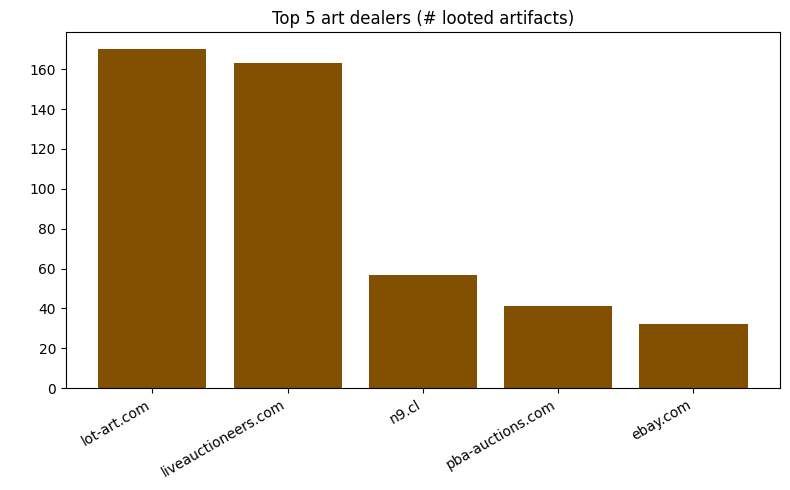

In [9]:
# additional graph in EDA about art dealers (based on sql script and export)

df = pd.read_csv("../data/clean/sql_exports/sql_query_top5_art_dealers_looted_artefacts.csv", sep = ";")

plt.figure(figsize=(8, 5))
plt.bar(df["art_dealer"], df["n_artifacts"], color = "#825000")

plt.title("Top 5 art dealers (# looted artifacts)")
plt.xlabel("")
plt.ylabel(" ")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../figures/top5_looted_artfcts_art_dealer.png", transparent=True)
plt.show()